This program 
- takes GRDC river discharge observation stations,
- matches them to the closest C-CWatM model grid cells,
- optionally adjusts the match manually,
- and then creates maps showing the yearly-summed discharge around each station so you can visually decide which grid cell is the “best raster cell” for calibration.

In [1]:
import netCDF4 as nc 
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import PIL 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pathlib import Path

# Read data

In [8]:
# Choose .nc file with in GRDC stations
filepath_observation = 'GRDC_data/'
selected_observation = 'GRDC_calibrationStations/GRDC_42calibrationStations_FINAL.nc'

# Filepath Simulation 
filepath_simulation = 'CWatM_exampleGrid'

# Outputfile path for Maps 
output_path = 'FindBestRaster/IndividualMapsBestRaster'

## Read GRDC observed discharge

In [9]:
# Read station data
observation_file = filepath_observation + '/' + selected_observation 
xr_obs = xr.open_dataset(observation_file)
xr_obs

# List of all unique station IDs
list_of_station_IDs = xr_obs['id'].values

# Dictionary for station names
Dict_stationname = {}
for ID in list_of_station_IDs:
    stationname = xr_obs['station_name'].sel(id = ID).values
    country = xr_obs['country'].sel(id = ID).values
    Dict_stationname[ID] = f"{stationname} ({country})"

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numba/__init__.py:149: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.4)
  import scipy


## Read C-CWatM simulated discharge

In [6]:
# ADJUST to your needs
start_date_sim = '01-01-2003' 
end_date_sim = '12-31-2003' 

In [8]:
# Read simulation data
simulation_file = filepath_simulation  + '/discharge_daily.nc' # This is a dummy file. ADJUST to your needs.
xr_sim = xr.open_dataset(simulation_file)

longitudes_sim = xr_sim['lon'].values
latitudes_sim = xr_sim['lat'].values
time_sim = xr_sim['time'].sel(time = slice (start_date_sim, end_date_sim)).values

# Distance between grid lines
step_lat = np.abs(latitudes_sim[1] - latitudes_sim[0])
step_lon = np.abs(longitudes_sim[1] - longitudes_sim[0])

# Select discharge variable
xr_sim_discharge = xr_sim['discharge'].sel(time = slice (start_date_sim, end_date_sim))   

# Prepare data

## Annual discharge sums for all simulaton grid cells

In [9]:
def calculate_yearly_sum(xr_data):
    selected_data = xr_data.sel(time = slice(start_date_sim, end_date_sim))
    yearly_sum = selected_data.sum(dim ='time')
    yearly_sum = yearly_sum.expand_dims(dim ='time')
    return yearly_sum

def control_dimensions(data_set):
    time_dim = np.shape(data_set)[0]
    lat_dim = np.shape(data_set)[1]
    lon_dim = np.shape(data_set)[2]
    return print('dimension of time = ' , time_dim , ', dimension of lattitudes = ' , lat_dim  , ', dimension of longitudes = ' , lon_dim)

xr_yearly_sum_discharge  = calculate_yearly_sum(xr_sim_discharge)
yearly_sum_discharge = xr_yearly_sum_discharge.values

control_dimensions(yearly_sum_discharge)

dimension of time =  1 , dimension of lattitudes =  437 , dimension of longitudes =  625


## Station coordinates

#### Find station latitudes and longitudes matching C-CWatM grid

In [10]:
lon_station = {}
lat_station = {}

for ID in list_of_station_IDs: 
    lon_station[ID] = xr_obs['geo_x'].sel(id = ID).values
    lat_station[ID] = xr_obs['geo_y'].sel(id = ID).values
    
# C-CWatM coordinates
latitudes = xr_sim['lat'].values
longitudes = xr_sim['lon'].values

# Find closest coordinates
lat_station_index = {}
lon_station_index = {}

for ID in list_of_station_IDs: 
    lat_station_index [ID] = np.abs(latitudes - lat_station[ID]).argmin()
    lon_station_index [ID] = np.abs(longitudes - lon_station[ID]).argmin()

#### Find lat and lon indeces around GRDC stations 

In [11]:
# Indeces of surrounding grid cells
lat_station_index_min = {}
lon_station_index_min = {}
lat_station_index_max = {}
lon_station_index_max = {}
for ID in list_of_station_IDs:
    lat_station_index_min [ID] = lat_station_index [ID] -2
    lat_station_index_max [ID] = lat_station_index [ID] +2
    lon_station_index_min [ID] = lon_station_index [ID] -2
    lon_station_index_max [ID] = lon_station_index [ID] +2

# Raster coordinates around stations
lat_station_min = {}
lon_station_min = {}
lat_station_max = {}
lon_station_max = {}
for ID in list_of_station_IDs:
    lat_station_min [ID] = latitudes[lat_station_index_min [ID]]
    lat_station_max [ID] = latitudes[lat_station_index_max [ID]] 
    lon_station_min [ID] = longitudes[lon_station_index_min [ID]]
    lon_station_max [ID] = longitudes[lon_station_index_max [ID]]

# border coordinates for plotting 
A_lat = {}
A_lon = {}
B_lat = {}
B_lon = {}
for ID in list_of_station_IDs:
    A_lat [ID] = min(lat_station_min [ID], lat_station_max [ID])
    A_lon [ID] = min(lon_station_min [ID], lon_station_max [ID])
    B_lat [ID] = max(lat_station_min [ID], lat_station_max [ID])
    B_lon [ID] = max(lon_station_min [ID], lon_station_max [ID])

## Find best fit for indices

In [12]:
# Copy station indeces, which are adjusted later
lat_station_index_fit = {} 
lon_station_index_fit = {}
for ID in list_of_station_IDs:
    lat_station_index_fit [ID] = lat_station_index [ID]
    lon_station_index_fit [ID] = lon_station_index [ID]

### Manual choice of LatFit und LonFit 
Choose which stations need to be adjusted manually 

In [13]:
### List station IDs that need adjustment here
list_of_station_IDs_lat_minus1 = [ 6212450 , 6226300 , 6227410 , 6226310 , 6227130 , 6217400 , 
                                   6605615 , 6139770 , 6221102 , 6348610 , 6935302 , 6233650 , 
                                   6233690 , 6854702 , 6854101 , 6172351 , 6573800 , 6335020 , 
                                   6337100 , 6337400 , 6546610 , 6781800 , 6457200 , 6444200 , 
                                   6444430 , 6213750 , 6123510 , 6124045 , 6935300 ] 
list_of_station_IDs_lon_minus1 = [ 6212740 , 6211520 , 6139284 , 6574300 , 6342500, 6342501 , 
                                   6144200 , 6227510 , 6123300 ]
list_of_station_IDs_lat_plus1  = [ 6340501 , 6227510 ]
list_of_station_IDs_lon_plus1  = [ 6216610 , 6172351 , 6340180 , 6546610 , 6373304 , 6744201,
                                   6118800 , 6742600 ]

### Adjust indices

In [14]:
lat_station_index_fit = {}
lon_station_index_fit = {}

for ID in list_of_station_IDs:
    lat_station_index_fit[ID] = lat_station_index[ID]
    lon_station_index_fit[ID] = lon_station_index[ID]
    
for ID in list_of_station_IDs_lat_minus1:
    if ID in list_of_station_IDs:
        lat_station_index_fit[ID] = lat_station_index[ID] - 1 
for ID in list_of_station_IDs_lon_minus1:
    if ID in list_of_station_IDs:
        lon_station_index_fit[ID] = lon_station_index[ID] - 1
for ID in list_of_station_IDs_lat_plus1:
    if ID in list_of_station_IDs:
        lat_station_index_fit[ID] = lat_station_index[ID] + 1 
for ID in list_of_station_IDs_lon_plus1:
    if ID in list_of_station_IDs:
        lon_station_index_fit[ID] = lon_station_index[ID] + 1

# Plotting to find "BestRaster"
Goal: Find, which manual adjustments are required

In [15]:
# User defined colormap
def custom_cmap():
    colors = [(0, 'white'), (1, 'blue')]
    cmap_name = 'custom_cmap'
    cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=256)
    return cmap
new_color = custom_cmap()

# Mesh-Grid for Cartopy 
lon, lat = np.meshgrid(longitudes_sim, latitudes_sim)
x, y = lon, lat 

--------------------------------------------------------------------------------------------------------
6113050  /  ALMOUROL (PT) :   lat & lon: 39.461 & -8.375
6113050  /  ALMOUROL (PT) :   lat index & lon index: 380 & 27
6113050  /  ALMOUROL (PT) :   lat index fit & lon index fit: 380 & 27


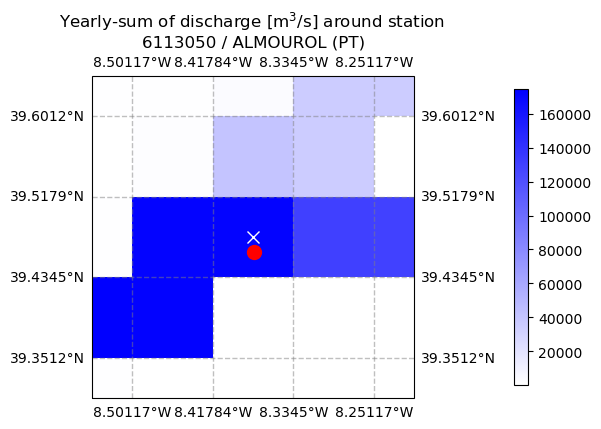

--------------------------------------------------------------------------------------------------------
6116200  /  PULO DO LOBO (PT) :   lat & lon: 37.803 & -7.633
6116200  /  PULO DO LOBO (PT) :   lat index & lon index: 400 & 36
6116200  /  PULO DO LOBO (PT) :   lat index fit & lon index fit: 400 & 36


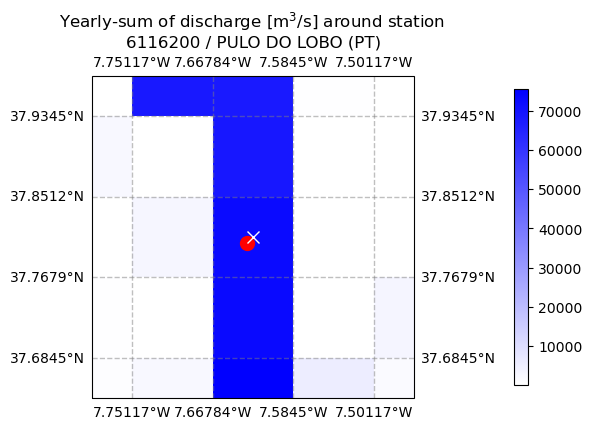

--------------------------------------------------------------------------------------------------------
6122260  /  PONT-SUR-SEINE (FR) :   lat & lon: 48.52376 & 3.59475
6122260  /  PONT-SUR-SEINE (FR) :   lat index & lon index: 271 & 171
6122260  /  PONT-SUR-SEINE (FR) :   lat index fit & lon index fit: 271 & 171


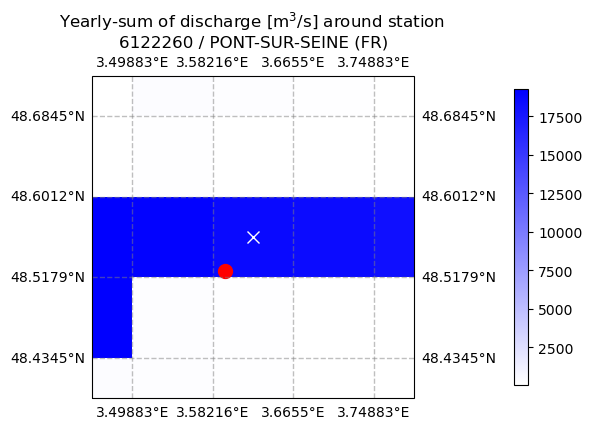

--------------------------------------------------------------------------------------------------------
6123510  /  MONTSOREAU ET A SAUMUR (FR) :   lat & lon: 47.26329 & -0.07434
6123510  /  MONTSOREAU ET A SAUMUR (FR) :   lat index & lon index: 287 & 127
6123510  /  MONTSOREAU ET A SAUMUR (FR) :   lat index fit & lon index fit: 286 & 127


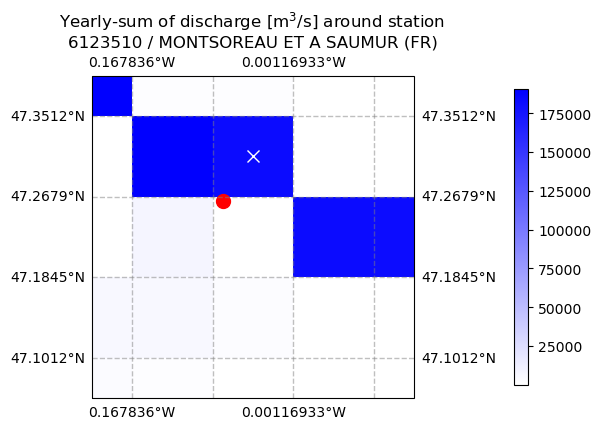

--------------------------------------------------------------------------------------------------------
6125100  /  MAS-D'AGENAIS (FR) :   lat & lon: 44.38892 & 0.30115
6125100  /  MAS-D'AGENAIS (FR) :   lat index & lon index: 321 & 131
6125100  /  MAS-D'AGENAIS (FR) :   lat index fit & lon index fit: 321 & 131


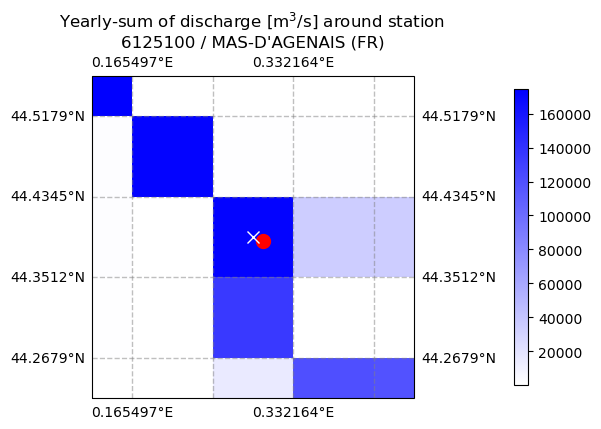

--------------------------------------------------------------------------------------------------------
6136145  /  UCKANGE (FR) :   lat & lon: 49.31672 & 6.17272
6136145  /  UCKANGE (FR) :   lat index & lon index: 262 & 202
6136145  /  UCKANGE (FR) :   lat index fit & lon index fit: 262 & 202


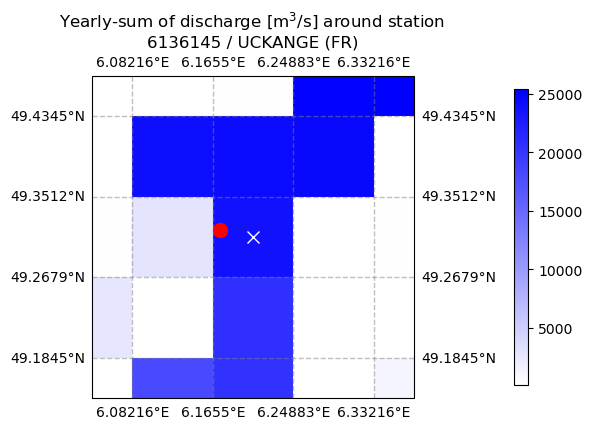

--------------------------------------------------------------------------------------------------------
6140400  /  DECIN (CZ) :   lat & lon: 50.78218 & 14.20955
6140400  /  DECIN (CZ) :   lat index & lon index: 244 & 298
6140400  /  DECIN (CZ) :   lat index fit & lon index fit: 244 & 298


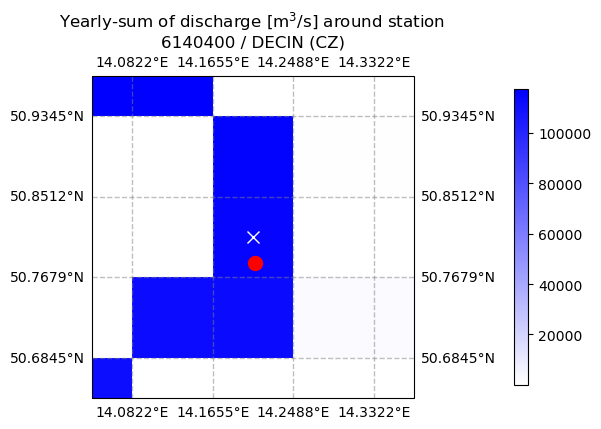

--------------------------------------------------------------------------------------------------------
6142150  /  MORAVSKY JAN (SK) :   lat & lon: 48.60213 & 16.93585
6142150  /  MORAVSKY JAN (SK) :   lat index & lon index: 270 & 331
6142150  /  MORAVSKY JAN (SK) :   lat index fit & lon index fit: 270 & 331


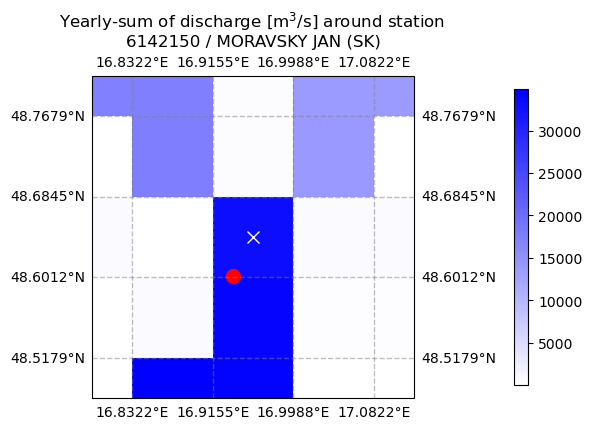

--------------------------------------------------------------------------------------------------------
6172050  /  OORE (EE) :   lat & lon: 58.46306 & 24.7675
6172050  /  OORE (EE) :   lat index & lon index: 152 & 425
6172050  /  OORE (EE) :   lat index fit & lon index fit: 152 & 425


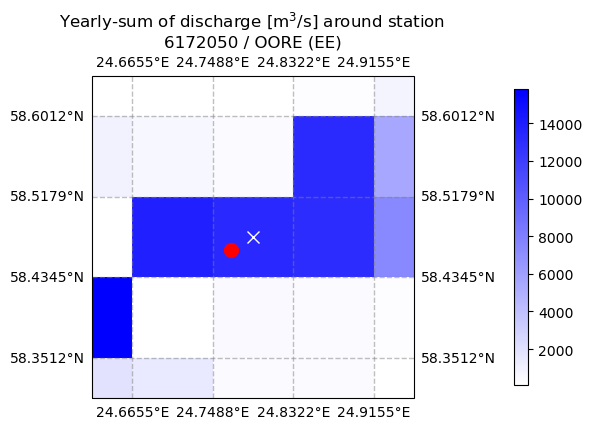

--------------------------------------------------------------------------------------------------------
6212410  /  TORO (ES) :   lat & lon: 41.51511 & -5.41283
6212410  /  TORO (ES) :   lat index & lon index: 356 & 63
6212410  /  TORO (ES) :   lat index fit & lon index fit: 356 & 63


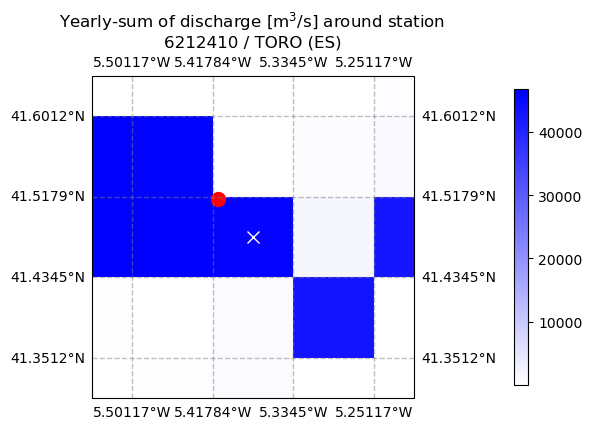

--------------------------------------------------------------------------------------------------------
6226800  /  TORTOSA (ES) :   lat & lon: 40.81328 & 0.52066
6226800  /  TORTOSA (ES) :   lat index & lon index: 364 & 134
6226800  /  TORTOSA (ES) :   lat index fit & lon index fit: 364 & 134


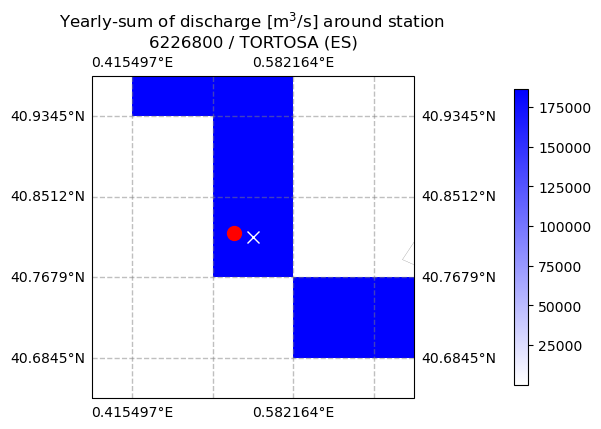

--------------------------------------------------------------------------------------------------------
6227510  /  HUERTO MULET (ES) :   lat & lon: 39.18695 & -0.41044
6227510  /  HUERTO MULET (ES) :   lat index & lon index: 383 & 123
6227510  /  HUERTO MULET (ES) :   lat index fit & lon index fit: 384 & 122


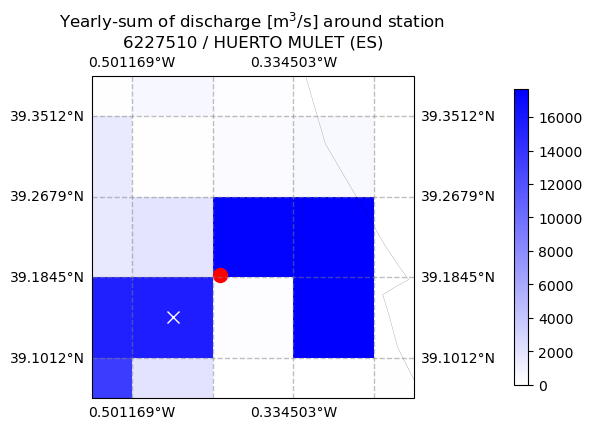

--------------------------------------------------------------------------------------------------------
6232911  /  PAJALA PUMPHUS (SE) :   lat & lon: 67.2074 & 23.3959
6232911  /  PAJALA PUMPHUS (SE) :   lat index & lon index: 47 & 408
6232911  /  PAJALA PUMPHUS (SE) :   lat index fit & lon index fit: 47 & 408


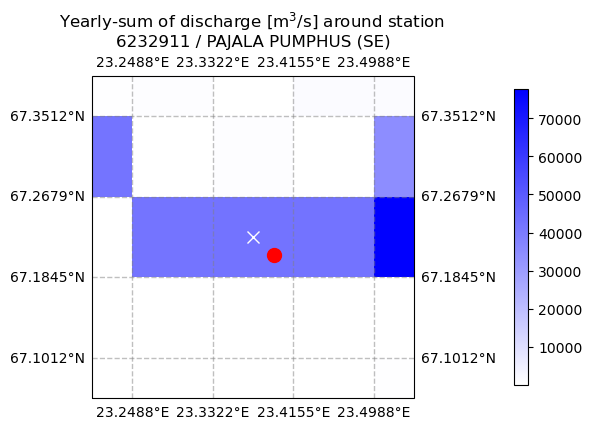

--------------------------------------------------------------------------------------------------------
6233410  /  OEVRE STOCKHOLM (SE) :   lat & lon: 59.3 & 18.07
6233410  /  OEVRE STOCKHOLM (SE) :   lat index & lon index: 142 & 344
6233410  /  OEVRE STOCKHOLM (SE) :   lat index fit & lon index fit: 142 & 344


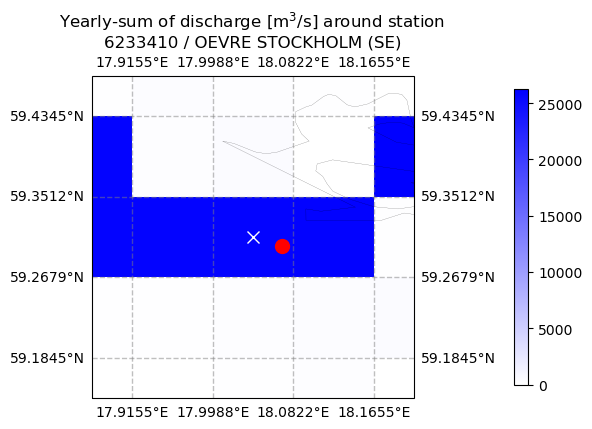

--------------------------------------------------------------------------------------------------------
6233510  /  GRANAKER (SE) :   lat & lon: 64.2233 & 19.7036
6233510  /  GRANAKER (SE) :   lat index & lon index: 83 & 364
6233510  /  GRANAKER (SE) :   lat index fit & lon index fit: 83 & 364


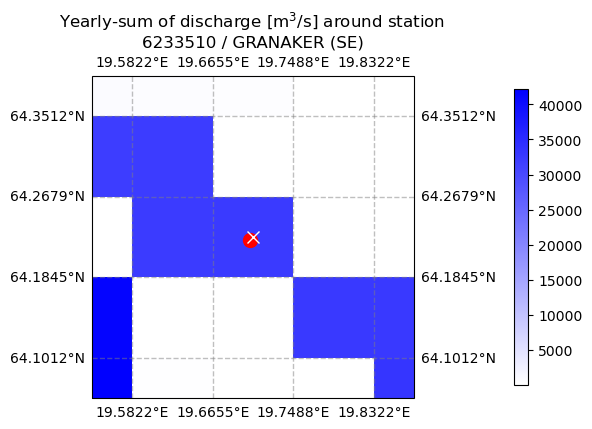

--------------------------------------------------------------------------------------------------------
6243050  /  KIRCHBICHL - BICHLWANG (AT) :   lat & lon: 47.52334 & 12.09389
6243050  /  KIRCHBICHL - BICHLWANG (AT) :   lat index & lon index: 283 & 273
6243050  /  KIRCHBICHL - BICHLWANG (AT) :   lat index fit & lon index fit: 283 & 273


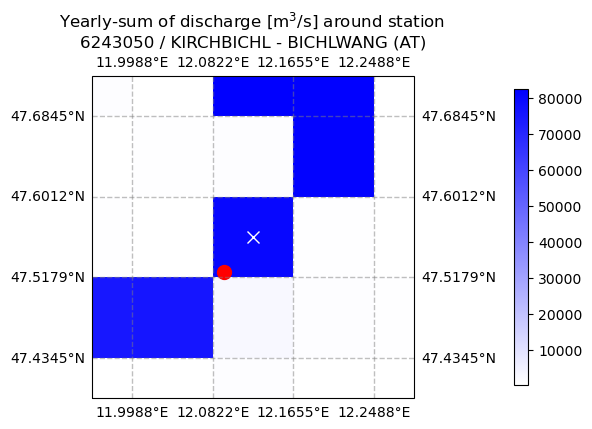

--------------------------------------------------------------------------------------------------------
6335240  /  KLEINHEUBACH (DE) :   lat & lon: 49.71648 & 9.22458
6335240  /  KLEINHEUBACH (DE) :   lat index & lon index: 257 & 238
6335240  /  KLEINHEUBACH (DE) :   lat index fit & lon index fit: 257 & 238


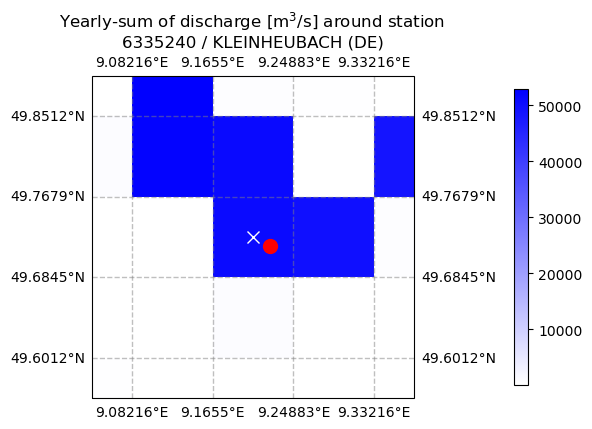

--------------------------------------------------------------------------------------------------------
6337200  /  INTSCHEDE (DE) :   lat & lon: 52.964 & 9.125
6337200  /  INTSCHEDE (DE) :   lat index & lon index: 218 & 237
6337200  /  INTSCHEDE (DE) :   lat index fit & lon index fit: 218 & 237


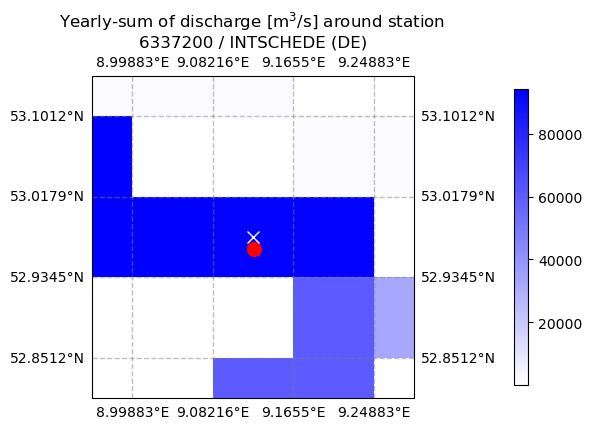

--------------------------------------------------------------------------------------------------------
6342501  /  DILLINGEN (DE) :   lat & lon: 48.5684 & 10.50053
6342501  /  DILLINGEN (DE) :   lat index & lon index: 271 & 254
6342501  /  DILLINGEN (DE) :   lat index fit & lon index fit: 271 & 253


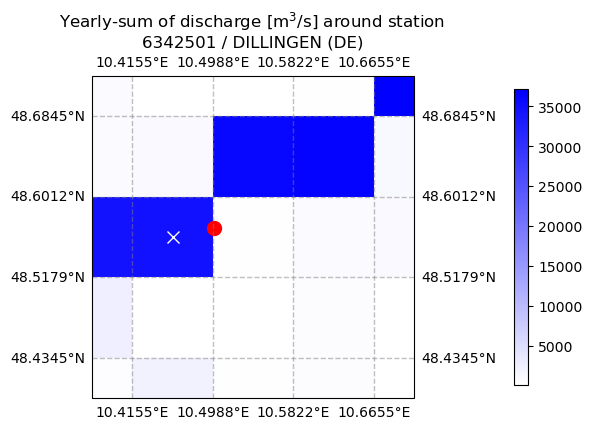

--------------------------------------------------------------------------------------------------------
6357500  /  EISENHUETTENSTADT (DE) :   lat & lon: 52.15361 & 14.68972
6357500  /  EISENHUETTENSTADT (DE) :   lat index & lon index: 228 & 304
6357500  /  EISENHUETTENSTADT (DE) :   lat index fit & lon index fit: 228 & 304


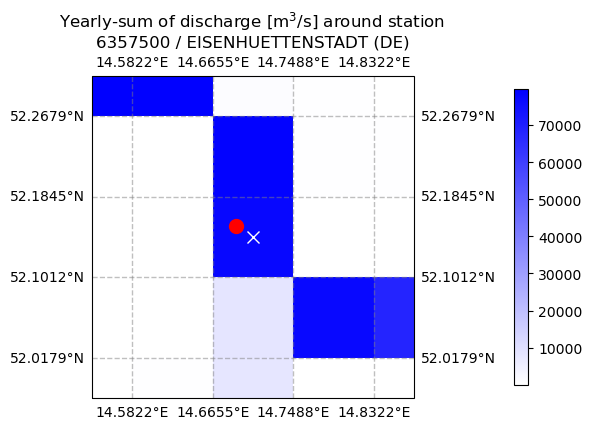

--------------------------------------------------------------------------------------------------------
6373304  /  JEKABPILS (LV) :   lat & lon: 56.4976 & 25.89148
6373304  /  JEKABPILS (LV) :   lat index & lon index: 176 & 438
6373304  /  JEKABPILS (LV) :   lat index fit & lon index fit: 176 & 439


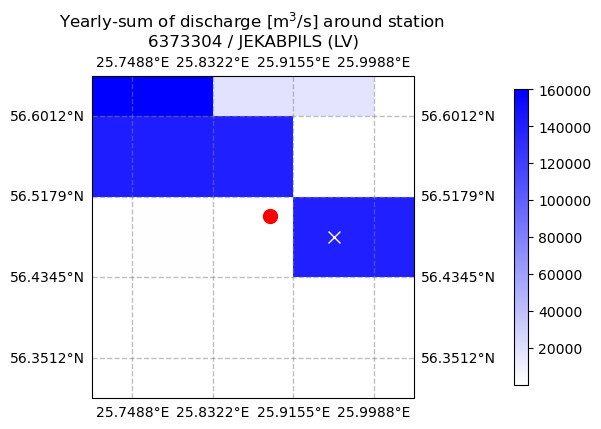

--------------------------------------------------------------------------------------------------------
6421100  /  LITH (NL) :   lat & lon: 51.82 & 5.45
6421100  /  LITH (NL) :   lat index & lon index: 232 & 193
6421100  /  LITH (NL) :   lat index fit & lon index fit: 232 & 193


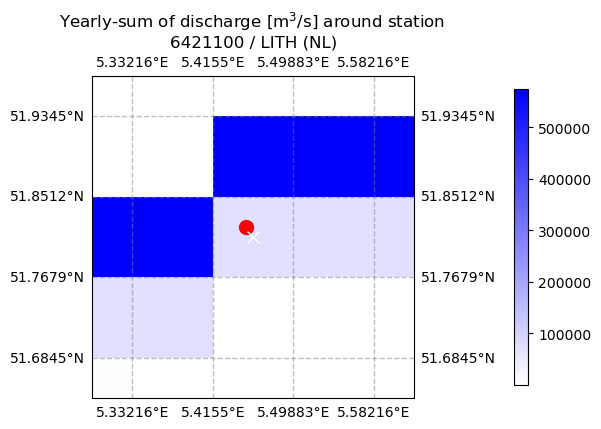

--------------------------------------------------------------------------------------------------------
6444600  /  CSENGER (HU) :   lat & lon: 47.8322 & 22.703
6444600  /  CSENGER (HU) :   lat index & lon index: 280 & 400
6444600  /  CSENGER (HU) :   lat index fit & lon index fit: 280 & 400


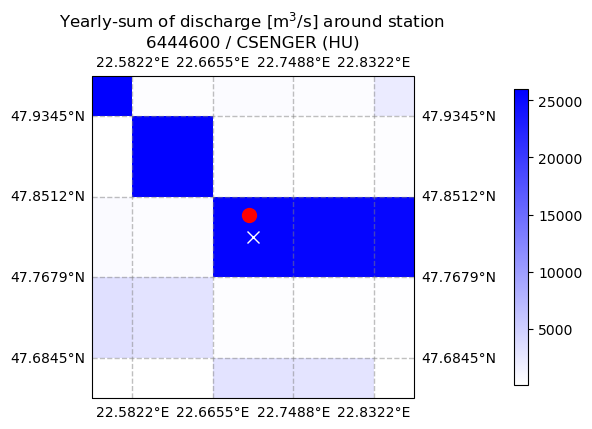

--------------------------------------------------------------------------------------------------------
6457870  /  NOWA WIES PODGORNA (PL) :   lat & lon: 52.14166 & 17.59
6457870  /  NOWA WIES PODGORNA (PL) :   lat index & lon index: 228 & 339
6457870  /  NOWA WIES PODGORNA (PL) :   lat index fit & lon index fit: 228 & 339


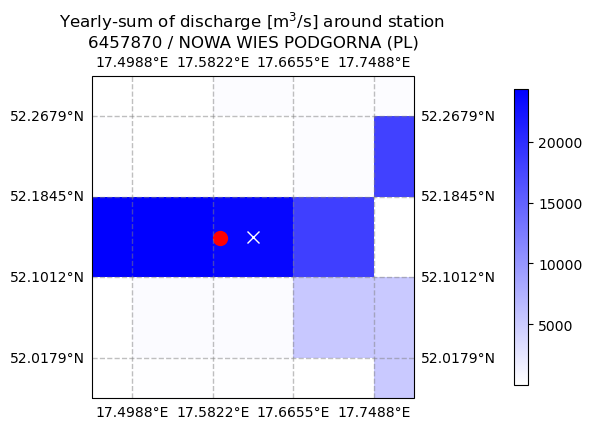

--------------------------------------------------------------------------------------------------------
6458450  /  SZCZUCIN (PL) :   lat & lon: 50.32694 & 21.07722
6458450  /  SZCZUCIN (PL) :   lat index & lon index: 250 & 380
6458450  /  SZCZUCIN (PL) :   lat index fit & lon index fit: 250 & 380


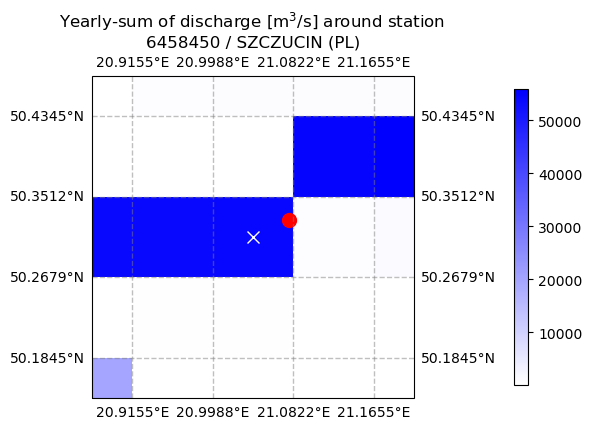

--------------------------------------------------------------------------------------------------------
6545050  /  CATEZ I (SI) :   lat & lon: 45.8932 & 15.6097
6545050  /  CATEZ I (SI) :   lat index & lon index: 303 & 315
6545050  /  CATEZ I (SI) :   lat index fit & lon index fit: 303 & 315


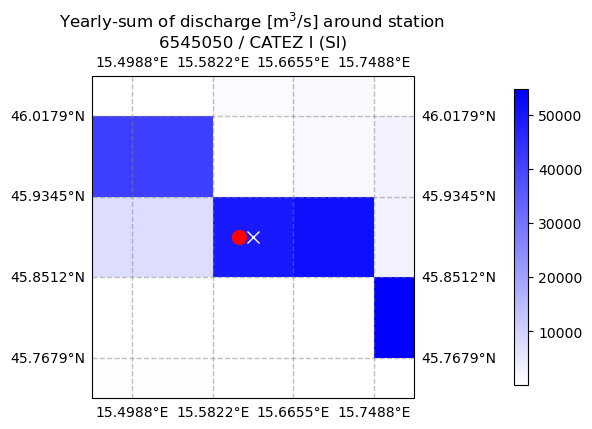

--------------------------------------------------------------------------------------------------------
6547110  /  JASIKA (RS) :   lat & lon: 43.60825 & 21.29516
6547110  /  JASIKA (RS) :   lat index & lon index: 330 & 383
6547110  /  JASIKA (RS) :   lat index fit & lon index fit: 330 & 383


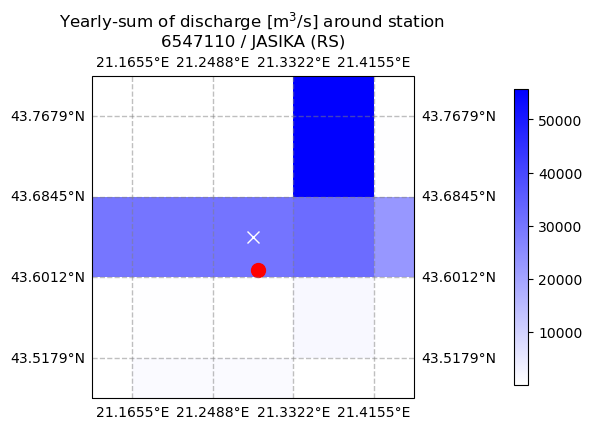

--------------------------------------------------------------------------------------------------------
6574150  /  SMALININKAI (LT) :   lat & lon: 55.07228 & 22.58592
6574150  /  SMALININKAI (LT) :   lat index & lon index: 193 & 399
6574150  /  SMALININKAI (LT) :   lat index fit & lon index fit: 193 & 399


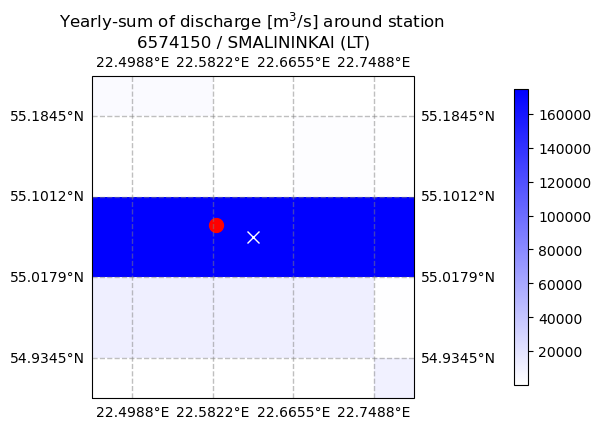

--------------------------------------------------------------------------------------------------------
6606655  /  KINGSTON (NATURALISED DISCHARGE) (GB) :   lat & lon: 51.41544 & -0.30771
6606655  /  KINGSTON (NATURALISED DISCHARGE) (GB) :   lat index & lon index: 237 & 124
6606655  /  KINGSTON (NATURALISED DISCHARGE) (GB) :   lat index fit & lon index fit: 237 & 124


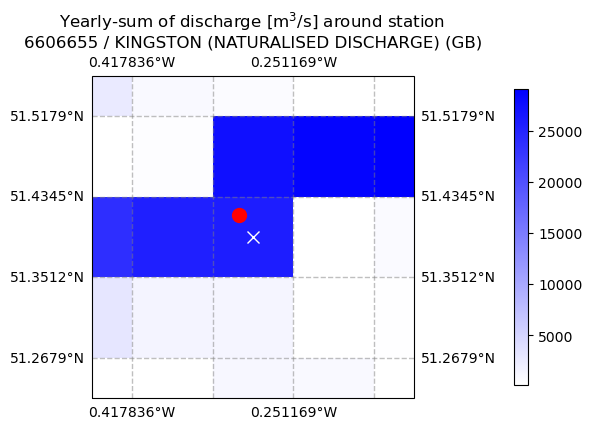

--------------------------------------------------------------------------------------------------------
6646800  /  DONJI MIHOLJAC C.S. (HR) :   lat & lon: 45.77464 & 18.17244
6646800  /  DONJI MIHOLJAC C.S. (HR) :   lat index & lon index: 304 & 346
6646800  /  DONJI MIHOLJAC C.S. (HR) :   lat index fit & lon index fit: 304 & 346


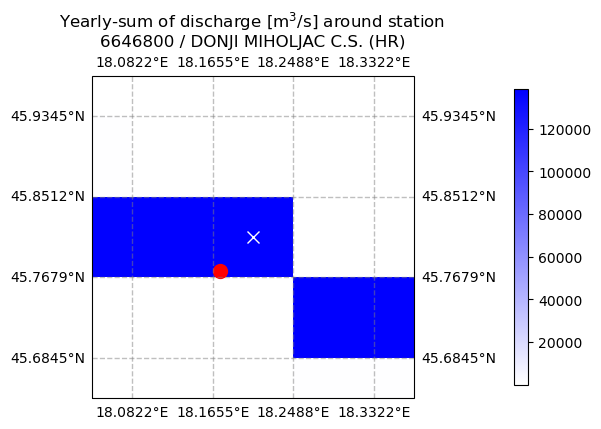

--------------------------------------------------------------------------------------------------------
6729450  /  LOSNA (NO) :   lat & lon: 61.33338 & 10.27753
6729450  /  LOSNA (NO) :   lat index & lon index: 118 & 251
6729450  /  LOSNA (NO) :   lat index fit & lon index fit: 118 & 251


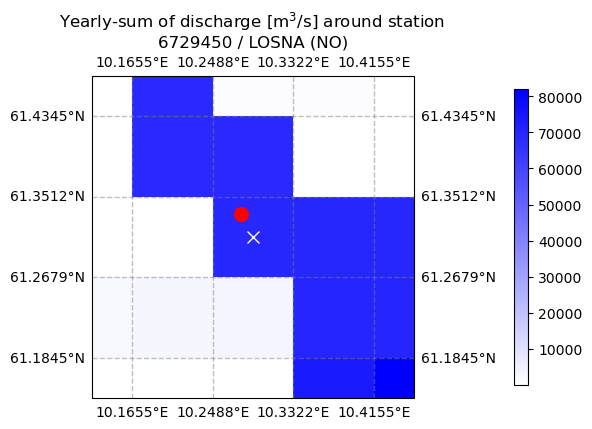

--------------------------------------------------------------------------------------------------------
6730501  /  POLMAK NYE (NO) :   lat & lon: 70.07034 & 28.01624
6730501  /  POLMAK NYE (NO) :   lat index & lon index: 13 & 464
6730501  /  POLMAK NYE (NO) :   lat index fit & lon index fit: 13 & 464


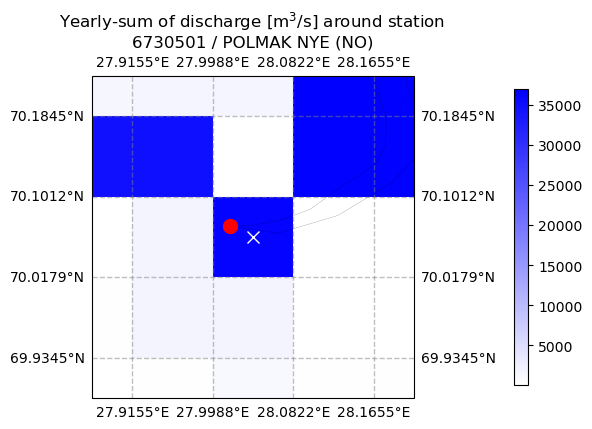

--------------------------------------------------------------------------------------------------------
6731555  /  BERTNEM (NO) :   lat & lon: 64.46807 & 12.05868
6731555  /  BERTNEM (NO) :   lat index & lon index: 80 & 272
6731555  /  BERTNEM (NO) :   lat index fit & lon index fit: 80 & 272


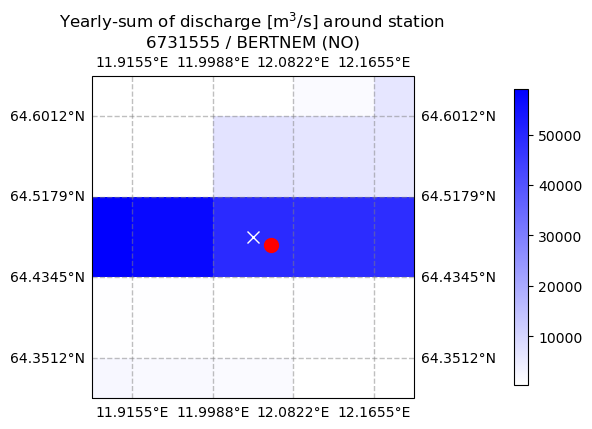

--------------------------------------------------------------------------------------------------------
6742700  /  LUNGOCI (RO) :   lat & lon: 45.55586 & 27.51222
6742700  /  LUNGOCI (RO) :   lat index & lon index: 307 & 458
6742700  /  LUNGOCI (RO) :   lat index fit & lon index fit: 307 & 458


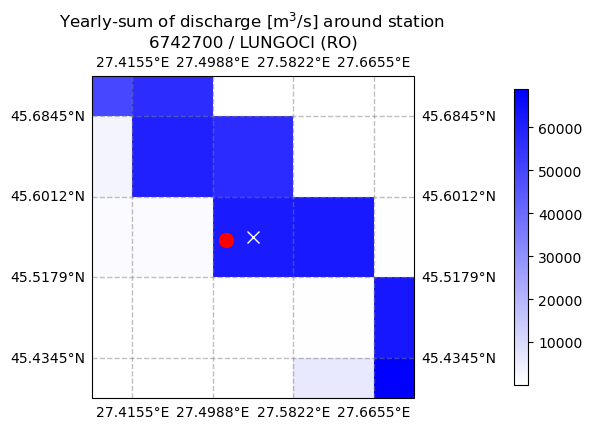

--------------------------------------------------------------------------------------------------------
6744201  /  ALBA IULIA (RO) :   lat & lon: 46.0375 & 23.58167
6744201  /  ALBA IULIA (RO) :   lat index & lon index: 301 & 410
6744201  /  ALBA IULIA (RO) :   lat index fit & lon index fit: 301 & 411


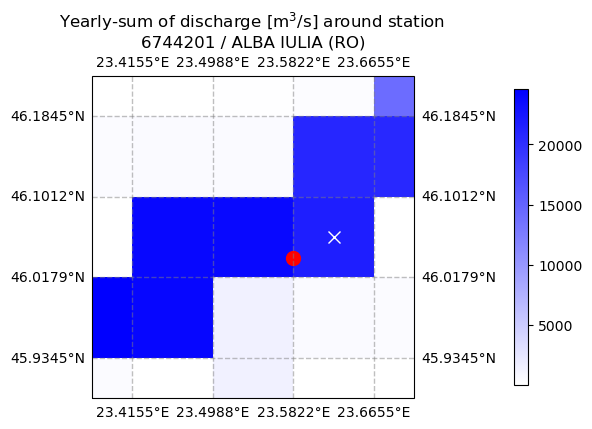

--------------------------------------------------------------------------------------------------------
6781800  /  TIGHINA (BENDERY) (MD) :   lat & lon: 46.83056 & 29.47111
6781800  /  TIGHINA (BENDERY) (MD) :   lat index & lon index: 292 & 481
6781800  /  TIGHINA (BENDERY) (MD) :   lat index fit & lon index fit: 291 & 481


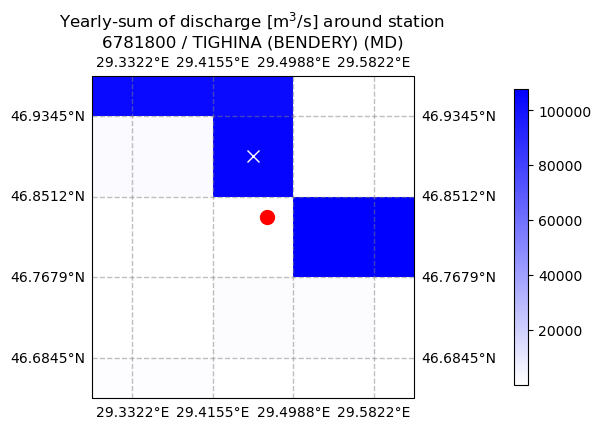

--------------------------------------------------------------------------------------------------------
6854250  /  LEPPAVESI, LUUSUA (FI) :   lat & lon: 62.245 & 25.8879
6854250  /  LEPPAVESI, LUUSUA (FI) :   lat index & lon index: 107 & 438
6854250  /  LEPPAVESI, LUUSUA (FI) :   lat index fit & lon index fit: 107 & 438


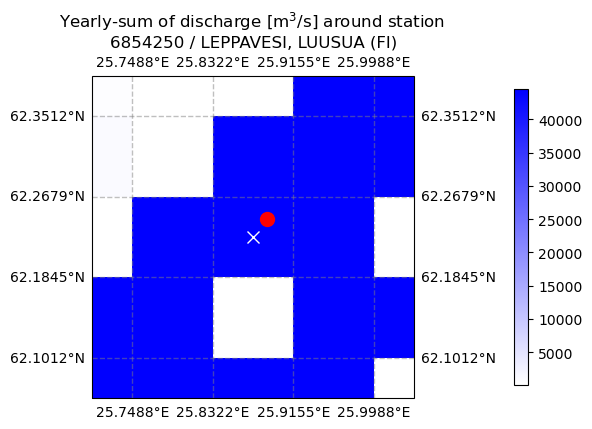

--------------------------------------------------------------------------------------------------------
6854700  /  ISOHAARA (FI) :   lat & lon: 65.7927 & 24.5453
6854700  /  ISOHAARA (FI) :   lat index & lon index: 64 & 422
6854700  /  ISOHAARA (FI) :   lat index fit & lon index fit: 64 & 422


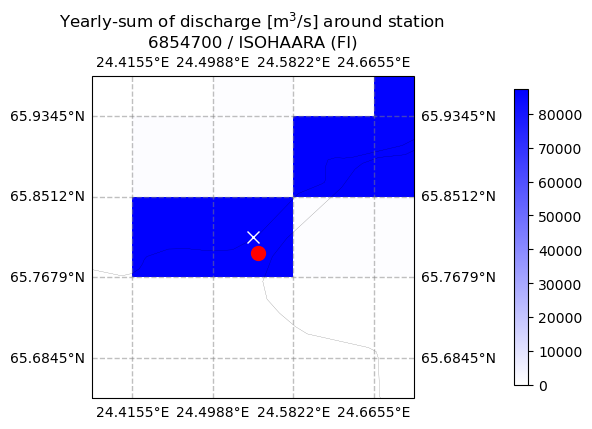

--------------------------------------------------------------------------------------------------------
6935051  /  BASEL, RHEINHALLE (CH) :   lat & lon: 47.5594 & 7.6167
6935051  /  BASEL, RHEINHALLE (CH) :   lat index & lon index: 283 & 219
6935051  /  BASEL, RHEINHALLE (CH) :   lat index fit & lon index fit: 283 & 219


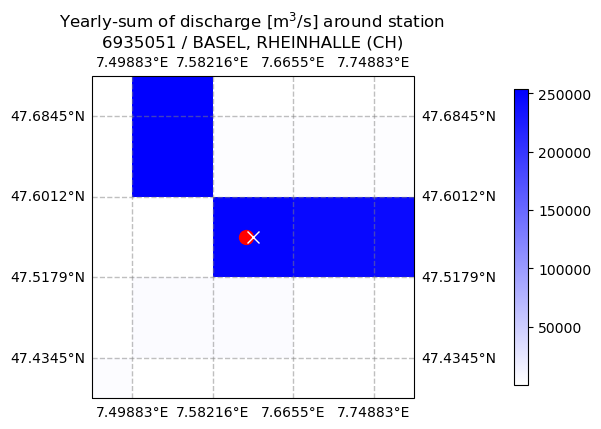

--------------------------------------------------------------------------------------------------------
6939050  /  CHANCY, AUX RIPES (CH) :   lat & lon: 46.153 & 5.9707
6939050  /  CHANCY, AUX RIPES (CH) :   lat index & lon index: 300 & 199
6939050  /  CHANCY, AUX RIPES (CH) :   lat index fit & lon index fit: 300 & 199


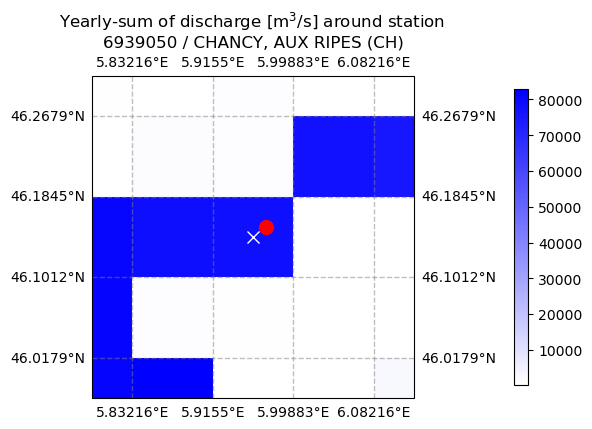

In [16]:
# Find the maximum and minimum values for z over the entire one‑year period for the highest modification at 100%

If you want, I can also rephrase it more formally, more technically, or more naturally depending on your context.Maximale und minimale Werte für z im Gesamten Zeitraum des einen Jahres herausfinden für die höchste Modifikation mit 100% 
z_min = {}
z_max = {}
for ID in list_of_station_IDs:
    z_id = np.squeeze(yearly_sum_discharge [ 0 , lat_station_index_min [ID] : lat_station_index_max [ID] + 1  , lon_station_index_min [ID] : lon_station_index_max [ID] +1 ])
    z_min [ID] = np.min(z_id)
    z_max [ID] = np.max(z_id)

# Discharge maps in Cartopy
for ID in list_of_station_IDs:
    print('--------------------------------------------------------------------------------------------------------')
    print(str(ID) , ' / ' , Dict_stationname[ID], ':  ', 'lat & lon:', np.round(lat_station[ID],5) ,  '&' , np.round(lon_station[ID],5))
    print(str(ID) , ' / ' , Dict_stationname[ID], ':  ', 'lat index & lon index:', lat_station_index[ID] , '&' , lon_station_index [ID])
    print(str(ID) , ' / ' , Dict_stationname[ID], ':  ', 'lat index fit & lon index fit:', lat_station_index_fit[ID] , '&' , lon_station_index_fit [ID])
    z = np.squeeze(yearly_sum_discharge[0,:,:])
    choosen_projection = ccrs.PlateCarree()   
    ax = plt.axes(projection = choosen_projection) 
    ax.set_extent([A_lon [ID], B_lon [ID], A_lat [ID], B_lat [ID]], crs = choosen_projection)
    z_color = ax.pcolormesh(x, y, z , cmap = new_color , vmin = z_min[ID], vmax = z_max[ID])
    color_bar = plt.colorbar(z_color, ax=ax, orientation='vertical', pad = 0.2 , shrink = 0.8)
    ax.coastlines(linewidth=0.1, linestyle='-')
    # Punkt für Station hinzufügen
    ax.plot(lon_station [ID], lat_station [ID], 'ro', markersize=10, transform=ccrs.PlateCarree())
    # Punkt für erwählte CWatM Zelle hinzufügen
    ax.plot(longitudes[lon_station_index_fit [ID] ], latitudes[lat_station_index_fit [ID] ], 'wx', markersize=8, transform=ccrs.PlateCarree())
    plt.title('Yearly-sum of discharge [m$^3$/s] around station \n' + str(ID) + ' / ' + Dict_stationname[ID] ) 
    xlocs = np.arange(A_lon [ID] - 0.5 * step_lon , B_lon [ID], step_lon)
    ylocs = np.arange(A_lat [ID] - 0.5 * step_lat,  B_lat [ID], step_lat)
    ax.gridlines(xlocs=xlocs, ylocs=ylocs, draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    plt.savefig(output_path + '/' + Dict_stationname[ID] + ' BestRaster' + '.jpg')
    plt.show()
    plt.close()

# Print coordinates

In [17]:
for ID in list_of_station_IDs:
    print(lat_station_index[ID])
print('---------------------')

for ID in list_of_station_IDs:
    print(lon_station_index[ID])
print('---------------------')

for ID in list_of_station_IDs:
    print(lat_station_index_fit[ID])
print('---------------------')

for ID in list_of_station_IDs:
    print(lon_station_index_fit[ID])
print('---------------------')

### ---------------------------------------- THE END ------------------------------------------- 